Libraries loaded.
Train: 76,996 | Val: 10,988 | Test: 22,011
Classes: ['가구/인테리어', '도서', '디지털/가전', '생활/건강', '스포츠/레저', '식품', '여가/생활편의', '출산/육아', '패션의류', '패션잡화', '화장품/미용']
TF-IDF vocab size: 50,000
Feature matrix   : (76996, 50000)
M1: TF-IDF + Logistic Regression (Baseline)
[TF-IDF + LR (Baseline)]  Acc=0.8569  Macro-F1=0.8566  Weighted-F1=0.8566
              precision    recall  f1-score   support

     가구/인테리어       0.84      0.81      0.82      2001
          도서       0.88      0.94      0.91      2001
      디지털/가전       0.88      0.87      0.87      2001
       생활/건강       0.67      0.69      0.68      2001
      스포츠/레저       0.81      0.80      0.81      2001
          식품       0.93      0.95      0.94      2001
     여가/생활편의       0.92      0.87      0.89      2001
       출산/육아       0.85      0.78      0.82      2001
        패션의류       0.89      0.92      0.91      2001
        패션잡화       0.84      0.87      0.85      2001
      화장품/미용       0.92      0.93      0.92      2001

   

C:\Users\ecredible\anaconda3\envs\diceml\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[TF-IDF + XGBoost]  Acc=0.8066  Macro-F1=0.8075  Weighted-F1=0.8075
              precision    recall  f1-score   support

     가구/인테리어       0.82      0.78      0.80      2001
          도서       0.78      0.92      0.84      2001
      디지털/가전       0.83      0.82      0.82      2001
       생활/건강       0.54      0.64      0.59      2001
      스포츠/레저       0.81      0.70      0.75      2001
          식품       0.87      0.89      0.88      2001
     여가/생활편의       0.91      0.81      0.86      2001
       출산/육아       0.80      0.71      0.75      2001
        패션의류       0.85      0.89      0.87      2001
        패션잡화       0.82      0.83      0.82      2001
      화장품/미용       0.89      0.89      0.89      2001

    accuracy                           0.81     22011
   macro avg       0.81      0.81      0.81     22011
weighted avg       0.81      0.81      0.81     22011

M3: TF-IDF + Random Forest
[TF-IDF + Random Forest]  Acc=0.7887  Macro-F1=0.7879  Weighted-F1=0.7879
              prec

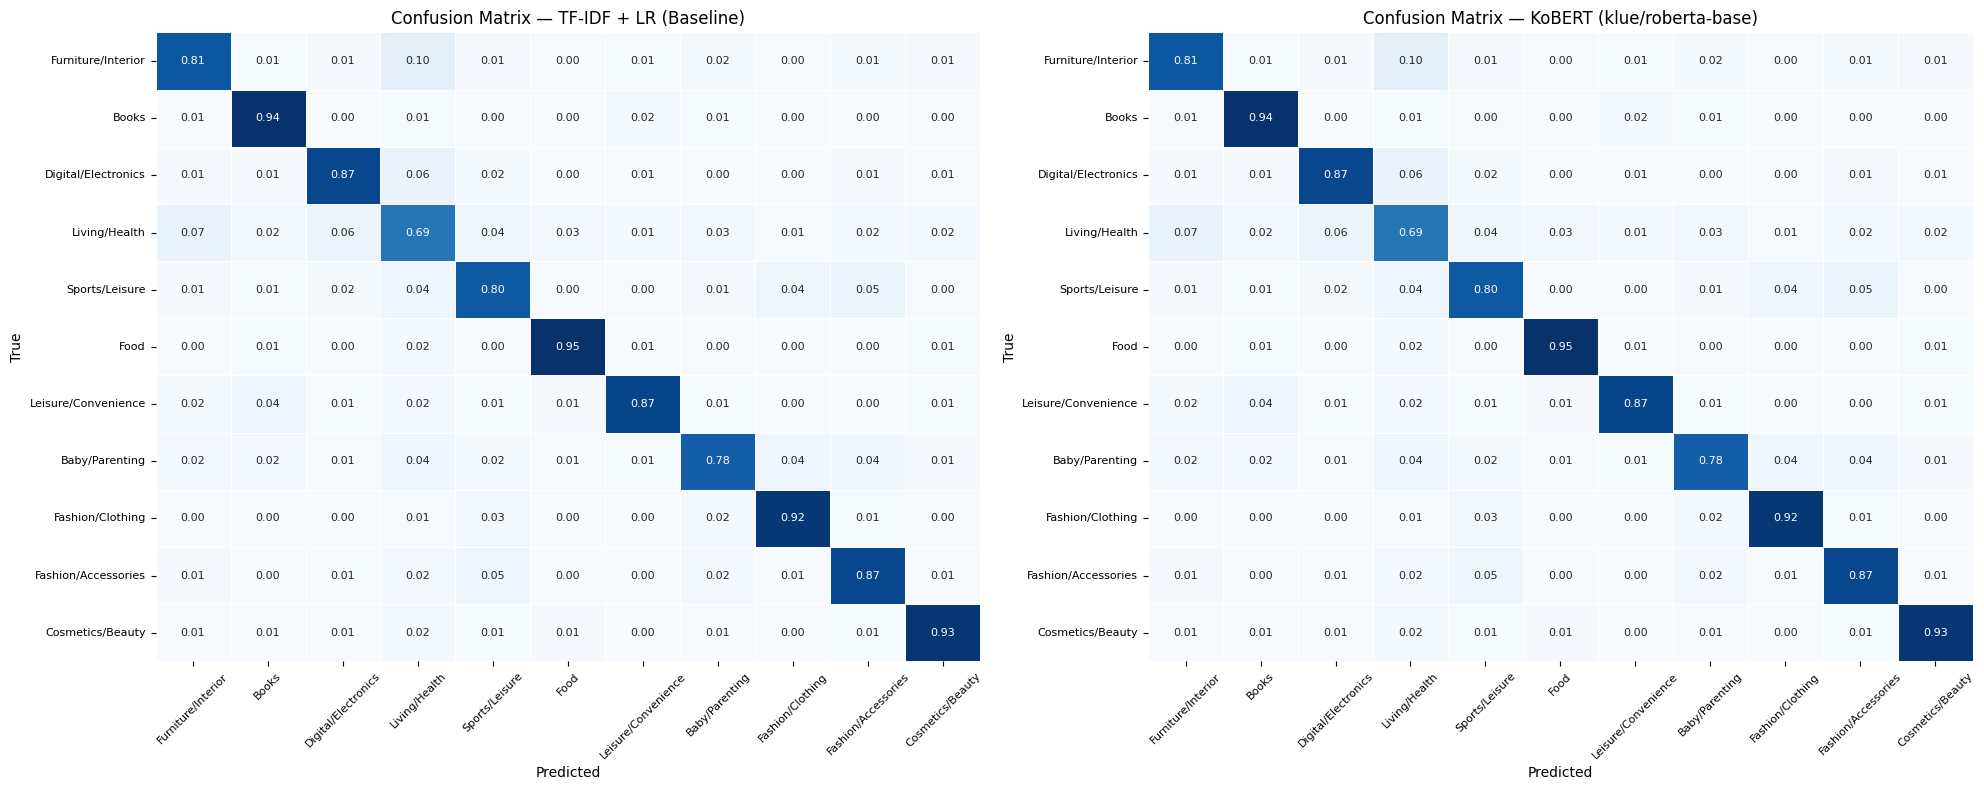

Saved → results/stage1_confusion_matrices.png
STAGE 1 SUMMARY
  Best model   : TF-IDF + LR (Baseline)
  Accuracy     : 0.8569
  Macro-F1     : 0.8566
  Weighted-F1  : 0.8566
Next → 03_stage2_aggregation_scs.ipynb


In [2]:
# =============================================================
# 02_stage1_model_comparison.ipynb
# Stage 1 — Product-Level Text Classification
# -------------------------------------------------------------
# Models : TF-IDF + LR (Baseline), XGBoost, Random Forest,
#          KoBERT (klue/roberta-base)
# Input  : data/train.csv, data/val.csv, data/test.csv
#          data/label_encoder.pkl
# Output : results/stage1_results.csv
#          results/stage1_confusion_matrices.png
#          models/best_tfidf_model.pkl
#          models/kobert_model/   (saved HuggingFace model)
#
# ── KoBERT (M4) requires the following before running ────────
# GPU (recommended):
#   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#   pip install transformers accelerate
# CPU only (slow, ~30min per epoch):
#   pip install torch torchvision torchaudio
#   pip install transformers
# =============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle, os, json, time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

os.makedirs('results', exist_ok=True)
os.makedirs('models',  exist_ok=True)

print("Libraries loaded.")


# ── Cell 2: Load Data ────────────────────────────────────────
train_df = pd.read_csv('data/train.csv')
val_df   = pd.read_csv('data/val.csv')
test_df  = pd.read_csv('data/test.csv')

with open('data/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Korean → English label mapping for paper figures
LABEL_EN = {
    '가구/인테리어' : 'Furniture/Interior',
    '도서'         : 'Books',
    '디지털/가전'   : 'Digital/Electronics',
    '생활/건강'     : 'Living/Health',
    '스포츠/레저'   : 'Sports/Leisure',
    '식품'         : 'Food',
    '여가/생활편의' : 'Leisure/Convenience',
    '출산/육아'     : 'Baby/Parenting',
    '패션의류'      : 'Fashion/Clothing',
    '패션잡화'      : 'Fashion/Accessories',
    '화장품/미용'   : 'Cosmetics/Beauty',
}
class_names_en = [LABEL_EN.get(c, c) for c in le.classes_]

X_train, y_train = train_df['prod_name'].values, train_df['label'].values
X_val,   y_val   = val_df['prod_name'].values,   val_df['label'].values
X_test,  y_test  = test_df['prod_name'].values,  test_df['label'].values

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
print(f"Classes: {le.classes_.tolist()}")


# ── Cell 3: TF-IDF Vectorizer ────────────────────────────────
# Character n-gram + word n-gram combined for Korean product names
tfidf = TfidfVectorizer(
    analyzer='char_wb',      # character n-gram (robust for Korean noisy text)
    ngram_range=(2, 4),
    max_features=50_000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF vocab size: {len(tfidf.vocabulary_):,}")
print(f"Feature matrix   : {X_train_tfidf.shape}")


# ── Cell 4: Helper — Evaluate Model ─────────────────────────
def evaluate(name, y_true, y_pred, elapsed=None):
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average='macro')
    wf1  = f1_score(y_true, y_pred, average='weighted')
    row  = {
        'model'   : name,
        'accuracy': round(acc, 4),
        'macro_f1': round(mf1, 4),
        'weighted_f1': round(wf1, 4),
        'train_time_sec': round(elapsed, 1) if elapsed else None
    }
    print(f"[{name}]  Acc={acc:.4f}  Macro-F1={mf1:.4f}  Weighted-F1={wf1:.4f}")
    return row

results = []


# ── Cell 5: M1 — Baseline: TF-IDF + Logistic Regression ─────
print("=" * 50)
print("M1: TF-IDF + Logistic Regression (Baseline)")
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=5.0, random_state=42,
                        class_weight='balanced', n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
elapsed = time.time() - t0

y_pred_lr_val  = lr.predict(X_val_tfidf)
y_pred_lr_test = lr.predict(X_test_tfidf)

results.append(evaluate("TF-IDF + LR (Baseline)",
                         y_test, y_pred_lr_test, elapsed))
print(classification_report(y_test, y_pred_lr_test,
                             target_names=le.classes_))


# ── Cell 6: M2 — TF-IDF + XGBoost ───────────────────────────
print("=" * 50)
print("M2: TF-IDF + XGBoost")
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, n_jobs=-1, tree_method='hist'
)
xgb.fit(X_train_tfidf, y_train,
        eval_set=[(X_val_tfidf, y_val)],
        verbose=False)
elapsed = time.time() - t0

y_pred_xgb_test = xgb.predict(X_test_tfidf)
results.append(evaluate("TF-IDF + XGBoost",
                         y_test, y_pred_xgb_test, elapsed))
print(classification_report(y_test, y_pred_xgb_test,
                             target_names=le.classes_))


# ── Cell 7: M3 — TF-IDF + Random Forest ─────────────────────
print("=" * 50)
print("M3: TF-IDF + Random Forest")
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_tfidf, y_train)
elapsed = time.time() - t0

y_pred_rf_test = rf.predict(X_test_tfidf)
results.append(evaluate("TF-IDF + Random Forest",
                         y_test, y_pred_rf_test, elapsed))
print(classification_report(y_test, y_pred_rf_test,
                             target_names=le.classes_))

# Save best TF-IDF model (LR typically best for text)
with open('models/best_tfidf_model.pkl', 'wb') as f:
    pickle.dump({'vectorizer': tfidf, 'model': lr}, f)
print("Saved → models/best_tfidf_model.pkl")


# ── Cell 8: M4 — KoBERT (klue/roberta-base) ─────────────────
# NOTE: Requires GPU recommended. CPU possible but slow.
print("=" * 50)
print("M4: KoBERT (klue/roberta-base)")

try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                              AdamW, get_linear_schedule_with_warmup)

    MODEL_NAME  = 'klue/roberta-base'
    MAX_LEN     = 64    # product names avg 32 chars — 64 tokens sufficient
    BATCH_SIZE  = 64
    EPOCHS      = 5
    LR_BERT     = 2e-5
    NUM_CLASSES = len(le.classes_)
    DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {DEVICE}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    class ProductDataset(Dataset):
        def __init__(self, texts, labels=None):
            self.texts  = texts
            self.labels = labels

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            enc = tokenizer(
                str(self.texts[idx]),
                max_length=MAX_LEN,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            item = {k: v.squeeze(0) for k, v in enc.items()}
            if self.labels is not None:
                item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
            return item

    train_ds = ProductDataset(X_train, y_train)
    val_ds   = ProductDataset(X_val,   y_val)
    test_ds  = ProductDataset(X_test,  y_test)

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES
    ).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=LR_BERT, weight_decay=0.01)
    total_steps = len(train_dl) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    # Training loop
    best_val_f1, best_epoch = 0, 0
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        # --- train ---
        model.train()
        total_loss = 0
        for batch in train_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        # --- validate ---
        model.eval()
        preds_val = []
        with torch.no_grad():
            for batch in val_dl:
                batch  = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                preds_val.extend(logits.argmax(-1).cpu().numpy())

        val_f1 = f1_score(y_val, preds_val, average='macro')
        print(f"  Epoch {epoch}/{EPOCHS} | Loss={total_loss/len(train_dl):.4f} | Val Macro-F1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            model.save_pretrained('models/kobert_model')
            tokenizer.save_pretrained('models/kobert_model')

    print(f"Best epoch: {best_epoch} (Val Macro-F1={best_val_f1:.4f})")

    # --- test evaluation ---
    model = AutoModelForSequenceClassification.from_pretrained(
        'models/kobert_model', num_labels=NUM_CLASSES
    ).to(DEVICE)
    model.eval()

    preds_test, probs_test = [], []
    with torch.no_grad():
        for batch in test_dl:
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            probs  = torch.softmax(logits, dim=-1)
            preds_test.extend(logits.argmax(-1).cpu().numpy())
            probs_test.extend(probs.cpu().numpy())

    elapsed = time.time() - t0
    results.append(evaluate("KoBERT (klue/roberta-base)",
                             y_test, preds_test, elapsed))
    print(classification_report(y_test, preds_test, target_names=le.classes_))

    # Save probabilities for Stage 2
    np.save('data/kobert_test_probs.npy', np.array(probs_test))
    np.save('data/kobert_test_preds.npy', np.array(preds_test))
    print("Saved → data/kobert_test_probs.npy")

except ImportError:
    print("torch / transformers not installed. Skipping M4.")
    print("Install: pip install torch transformers")


# ── Cell 9: Results Summary Table ───────────────────────────
results_df = pd.DataFrame(results)
print("\n" + "=" * 65)
print("STAGE 1 — MODEL COMPARISON RESULTS (Test Set)")
print("=" * 65)
print(results_df.to_string(index=False))
results_df.to_csv('results/stage1_results.csv', index=False)
print("\nSaved → results/stage1_results.csv")


# ── Cell 10: Confusion Matrix Visualization ──────────────────
# Plot confusion matrix for best ML model (LR) and KoBERT if available
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (name, preds) in zip(axes, [
    ("TF-IDF + LR (Baseline)", y_pred_lr_test),
    ("KoBERT (klue/roberta-base)", preds_test if 'preds_test' in dir() else y_pred_lr_test)
]):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names_en,
                yticklabels=class_names_en,
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={"size": 8})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('results/stage1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/stage1_confusion_matrices.png")


# ── Cell 11: Summary ─────────────────────────────────────────
print("=" * 55)
print("STAGE 1 SUMMARY")
print("=" * 55)
best_row = results_df.loc[results_df['macro_f1'].idxmax()]
print(f"  Best model   : {best_row['model']}")
print(f"  Accuracy     : {best_row['accuracy']}")
print(f"  Macro-F1     : {best_row['macro_f1']}")
print(f"  Weighted-F1  : {best_row['weighted_f1']}")
print("=" * 55)
print("Next → 03_stage2_aggregation_scs.ipynb")